# PCFG Trainer
Trains a **Probabilistic Context-Free Grammar** on a single split password file.

Run cells top to bottom. All outputs (JSON ruleset, probability tables, charts) are saved automatically into a dedicated folder.

---

## Cell 1 — Configuration
Set the path to your chosen split file. Everything else is derived automatically.

In [1]:
import os

# ── CONFIGURE THIS ────────────────────────────────────────────────
INPUT_FILE = "split_output/rockyou_len8.txt"  # <-- change to your chosen length file
BASE_OUTPUT_DIR = "pcfg_output"               # <-- parent folder for all PCFG outputs
# ─────────────────────────────────────────────────────────────────

# Auto-derive output folder name from input filename
# e.g. rockyou_len8.txt → pcfg_output/pcfg_len8/
basename    = os.path.splitext(os.path.basename(INPUT_FILE))[0]  # rockyou_len8
length_tag  = basename.replace("rockyou_", "")                   # len8
OUTPUT_DIR  = os.path.join(BASE_OUTPUT_DIR, f"pcfg_{length_tag}")

if not os.path.isfile(INPUT_FILE):
    raise FileNotFoundError(f"File not found: {INPUT_FILE}\nCheck your INPUT_FILE path above.")

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"nput file  : {INPUT_FILE}")
print(f"Size        : {os.path.getsize(INPUT_FILE) / 1_000_000:.2f} MB")
print(f"Output dir  : {OUTPUT_DIR}")

nput file  : split_output/rockyou_len8.txt
Size        : 26.72 MB
Output dir  : pcfg_output/pcfg_len8


## Cell 2 — Read & Tokenise
Every password is broken into typed segments:
- **L** = consecutive letters
- **D** = consecutive digits
- **S** = consecutive symbols

`hello123!` → `(L, hello)(D, 123)(S, !)` → structural tag `L5D3S1`

In [2]:
import re
from collections import Counter, defaultdict

def tokenise(password):
    """Split password into (type, value) segments."""
    segments = []
    for match in re.finditer(r'[A-Za-z]+|[0-9]+|[^A-Za-z0-9]+', password):
        val = match.group()
        if val[0].isalpha():
            segments.append(('L', val))
        elif val[0].isdigit():
            segments.append(('D', val))
        else:
            segments.append(('S', val))
    return segments

def structure_tag(segments):
    """e.g. [('L','hello'),('D','123')] → 'L5D3'"""
    return ''.join(f"{t}{len(v)}" for t, v in segments)

def cap_mask(word):
    """Capitalisation mask: 'Hello' → 'Ullll', 'HELLO' → 'UUUUU'"""
    return ''.join('U' if c.isupper() else 'l' for c in word)

# ── Counters ───────────────────────────────────────────────────────
structure_counts  = Counter()
digit_counts      = Counter()
symbol_counts     = Counter()
cap_mask_counts   = Counter()
base_word_counts  = defaultdict(Counter)  # keyed by word length
digit_pos_counts  = Counter()
symbol_pos_counts = Counter()
length_counts     = Counter()

total = 0

with open(INPUT_FILE, 'r', encoding='utf-8', errors='ignore') as f:
    for line in f:
        pw = line.rstrip('\n')
        if not pw:
            continue

        segs = tokenise(pw)
        tag  = structure_tag(segs)

        structure_counts[tag] += 1
        length_counts[len(pw)] += 1

        for i, (t, v) in enumerate(segs):
            pos = 'first' if i == 0 else ('last' if i == len(segs) - 1 else 'middle')
            if t == 'D':
                digit_counts[v] += 1
                digit_pos_counts[pos] += 1
            elif t == 'S':
                symbol_counts[v] += 1
                symbol_pos_counts[pos] += 1
            elif t == 'L':
                base_word_counts[len(v)][v.lower()] += 1
                cap_mask_counts[cap_mask(v)] += 1

        total += 1
        if total % 500_000 == 0:
            print(f"  … tokenised {total:,} passwords")

print(f"\nTokenisation complete")
print(f"Total passwords processed : {total:,}")
print(f"Unique structural patterns : {len(structure_counts):,}")
print(f"Unique base words          : {sum(len(v) for v in base_word_counts.values()):,}")
print(f"Unique digit strings       : {len(digit_counts):,}")
print(f"Unique symbol strings      : {len(symbol_counts):,}")

  … tokenised 500,000 passwords
  … tokenised 1,000,000 passwords
  … tokenised 1,500,000 passwords
  … tokenised 2,000,000 passwords
  … tokenised 2,500,000 passwords

Tokenisation complete
Total passwords processed : 2,966,956
Unique structural patterns : 3,220
Unique base words          : 1,245,441
Unique digit strings       : 579,972
Unique symbol strings      : 2,225


## Cell 3 — Build Probability Tables
Converts all raw counts into probability distributions ranked by likelihood.

In [3]:
def to_prob_table(counter, top_n=None):
    """Convert a Counter to a ranked probability table."""
    total = sum(counter.values())
    if total == 0:
        return []
    items = counter.most_common(top_n)
    return [{"value": k, "count": v, "probability": round(v / total, 6)} for k, v in items]

# Flatten base_word_counts (all lengths combined) for top-level table
all_base_words = Counter()
for length_bucket in base_word_counts.values():
    all_base_words.update(length_bucket)

# Base words per length bucket (used for generation later)
base_words_by_length = {
    length: to_prob_table(counter, top_n=None)
    for length, counter in base_word_counts.items()
}

ruleset = {
    "meta": {
        "input_file"              : INPUT_FILE,
        "total_passwords_trained" : total,
        "output_dir"              : OUTPUT_DIR,
    },
    "structures"        : to_prob_table(structure_counts,  top_n=300),
    "digit_strings"     : to_prob_table(digit_counts,      top_n=500),
    "symbol_strings"    : to_prob_table(symbol_counts,     top_n=200),
    "cap_masks"         : to_prob_table(cap_mask_counts,   top_n=100),
    "base_words"        : to_prob_table(all_base_words,    top_n=1000),
    "base_words_by_length": base_words_by_length,
    "digit_positions"   : to_prob_table(digit_pos_counts),
    "symbol_positions"  : to_prob_table(symbol_pos_counts),
    "password_lengths"  : to_prob_table(length_counts),
}

print("Probability tables built")
print(f"Top structure : {ruleset['structures'][0]['value']} "
      f"({ruleset['structures'][0]['probability']*100:.2f}%)")
print(f"Top base word : {ruleset['base_words'][0]['value']} "
      f"({ruleset['base_words'][0]['probability']*100:.2f}%)")
print(f"Top digit str : {ruleset['digit_strings'][0]['value']} "
      f"({ruleset['digit_strings'][0]['probability']*100:.2f}%)" if ruleset['digit_strings'] else "   No digit strings found")


Probability tables built
Top structure : L8 (25.54%)
Top base word : a (0.76%)
Top digit str : 1 (7.15%)


## Cell 4 — Export JSON Ruleset

In [4]:
import json

json_path = os.path.join(OUTPUT_DIR, "ruleset.json")
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(ruleset, f, indent=2)

size_kb = os.path.getsize(json_path) / 1024
print(f"JSON ruleset saved")
print(f"Path : {json_path}")
print(f"Size : {size_kb:.1f} KB")

JSON ruleset saved
Path : pcfg_output/pcfg_len8/ruleset.json
Size : 114775.0 KB


## Cell 5 — Export Plain Text Probability Tables

In [5]:
txt_path = os.path.join(OUTPUT_DIR, "probability_tables.txt")

sections = [
    ("TOP 30 STRUCTURAL PATTERNS  (L=letters, D=digits, S=symbols)", "structures",    30),
    ("TOP 30 DIGIT STRINGS",                                         "digit_strings",  30),
    ("TOP 20 SYMBOL STRINGS",                                        "symbol_strings", 20),
    ("TOP 20 CAPITALISATION MASKS  (U=upper, l=lower)",              "cap_masks",      20),
    ("TOP 50 BASE WORDS",                                            "base_words",     50),
    ("DIGIT POSITIONS",                                              "digit_positions", None),
    ("SYMBOL POSITIONS",                                             "symbol_positions", None),
    ("PASSWORD LENGTH DISTRIBUTION",                                 "password_lengths", None),
]

lines = []
lines.append("=" * 65)
lines.append("  PCFG PROBABILITY TABLES")
lines.append(f"  Input  : {INPUT_FILE}")
lines.append(f"  Trained: {total:,} passwords")
lines.append("=" * 65)

for title, key, limit in sections:
    rows = ruleset[key][:limit] if limit else ruleset[key]
    if not rows:
        continue
    lines.append("")
    lines.append("-" * 65)
    lines.append(f"  {title}")
    lines.append("-" * 65)
    lines.append(f"  {'Value':<22} {'Count':>10}  {'Probability':>12}")
    for r in rows:
        lines.append(f"  {str(r['value']):<22} {r['count']:>10,}  {r['probability']:>12.4%}")

with open(txt_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))

print(f"Plain text tables saved")
print(f"Path : {txt_path}")

Plain text tables saved
Path : pcfg_output/pcfg_len8/probability_tables.txt


## Cell 6 — Chart: Top Structural Patterns

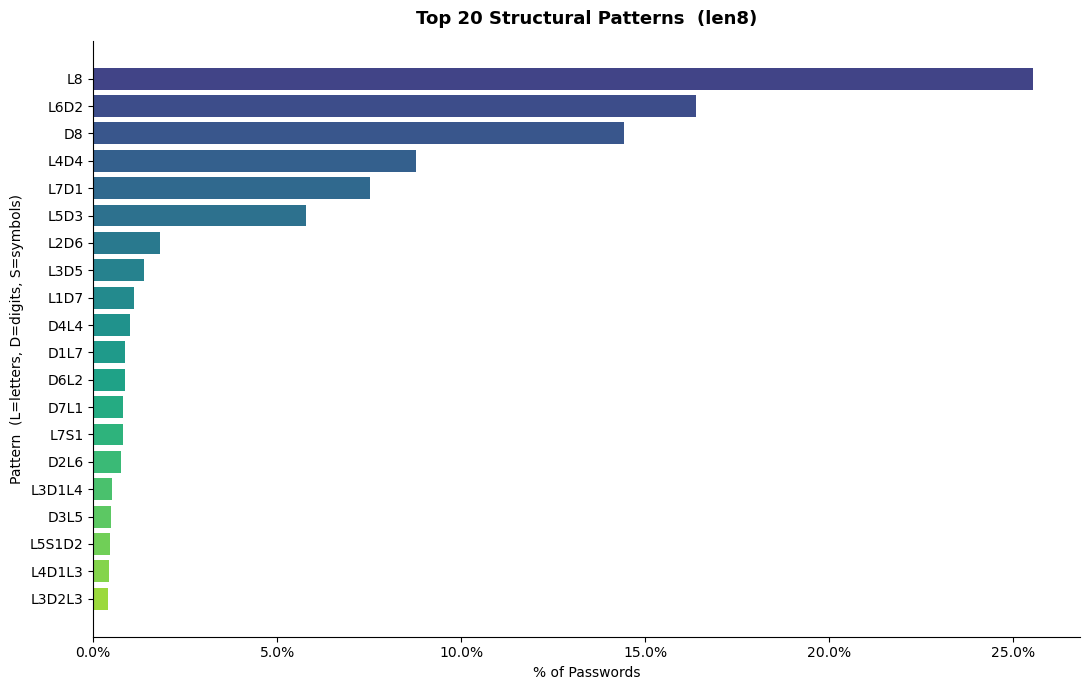

Saved → pcfg_output/pcfg_len8/chart_structures.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

top = ruleset['structures'][:20]
labels = [r['value'] for r in top]
values = [r['probability'] * 100 for r in top]
colors = plt.get_cmap('viridis')(np.linspace(0.2, 0.85, len(labels)))

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(labels[::-1], values[::-1], color=colors[::-1])
ax.set_title(f"Top 20 Structural Patterns  ({length_tag})",
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("% of Passwords", fontsize=10)
ax.set_ylabel("Pattern  (L=letters, D=digits, S=symbols)", fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
p = os.path.join(OUTPUT_DIR, 'chart_structures.png')
plt.savefig(p, dpi=150)
plt.show()
print(f"Saved → {p}")

## Cell 7 — Chart: Top Digit Strings

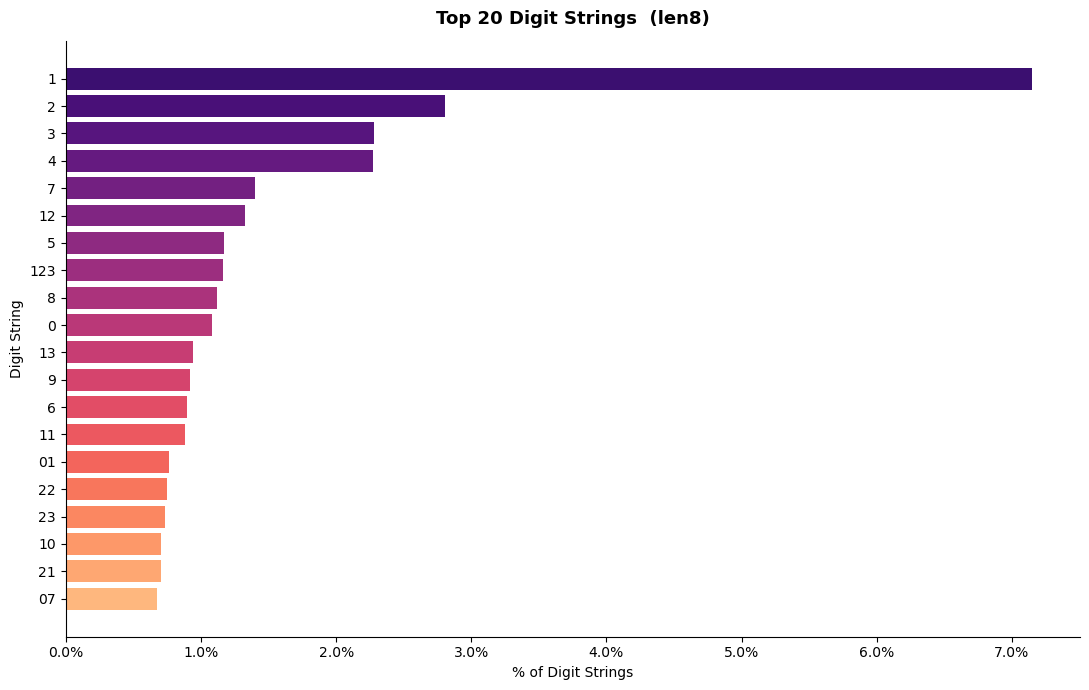

Saved → pcfg_output/pcfg_len8/chart_digits.png


In [7]:
top = ruleset['digit_strings'][:20]
if top:
    labels = [r['value'] for r in top]
    values = [r['probability'] * 100 for r in top]
    colors = plt.get_cmap('magma')(np.linspace(0.2, 0.85, len(labels)))

    fig, ax = plt.subplots(figsize=(11, 7))
    ax.barh(labels[::-1], values[::-1], color=colors[::-1])
    ax.set_title(f"Top 20 Digit Strings  ({length_tag})",
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel("% of Digit Strings", fontsize=10)
    ax.set_ylabel("Digit String", fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    p = os.path.join(OUTPUT_DIR, 'chart_digits.png')
    plt.savefig(p, dpi=150)
    plt.show()
    print(f"Saved → {p}")
else:
    print("No digit strings found in this file — chart skipped")

## Cell 8 — Chart: Top Symbol Strings

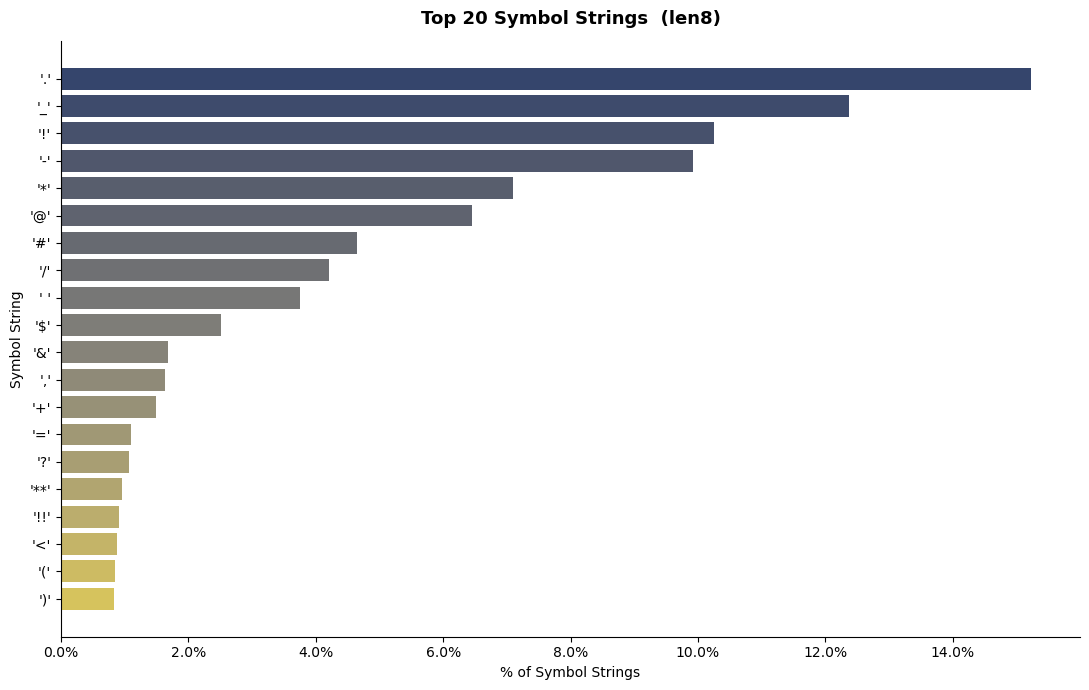

Saved → pcfg_output/pcfg_len8/chart_symbols.png


In [8]:
top = ruleset['symbol_strings'][:20]
if top:
    labels = [repr(r['value']) for r in top]
    values = [r['probability'] * 100 for r in top]
    colors = plt.get_cmap('cividis')(np.linspace(0.2, 0.85, len(labels)))

    fig, ax = plt.subplots(figsize=(11, 7))
    ax.barh(labels[::-1], values[::-1], color=colors[::-1])
    ax.set_title(f"Top 20 Symbol Strings  ({length_tag})",
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel("% of Symbol Strings", fontsize=10)
    ax.set_ylabel("Symbol String", fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    p = os.path.join(OUTPUT_DIR, 'chart_symbols.png')
    plt.savefig(p, dpi=150)
    plt.show()
    print(f"Saved → {p}")
else:
    print("ℹNo symbol strings found in this file — chart skipped")

## Cell 9 — Chart: Capitalisation Masks

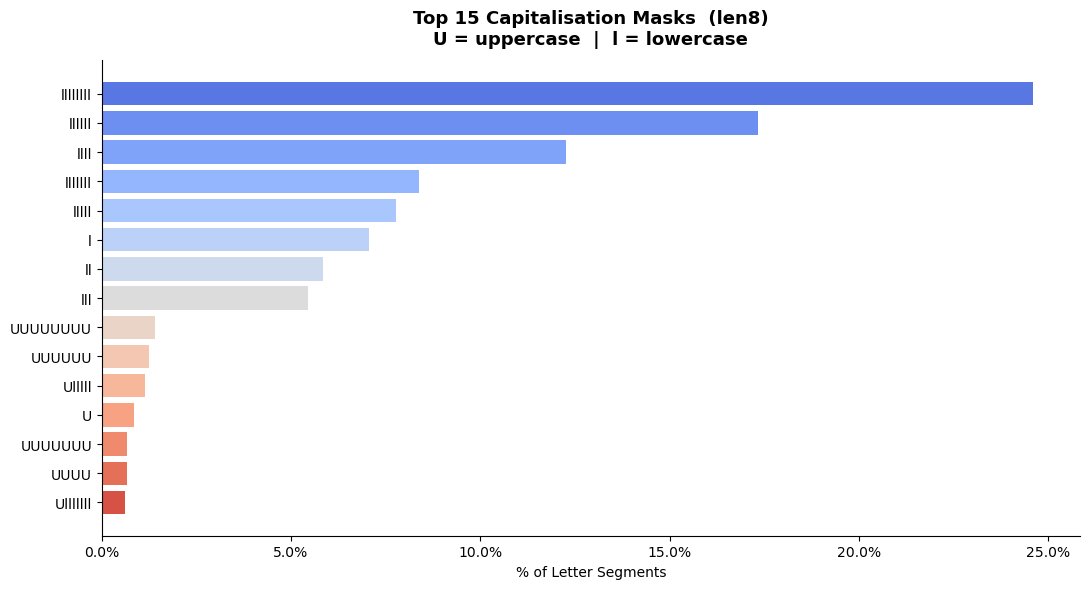

Saved → pcfg_output/pcfg_len8/chart_cap_masks.png


In [9]:
top = ruleset['cap_masks'][:15]
if top:
    labels = [r['value'] if len(r['value']) <= 12 else r['value'][:11] + '…' for r in top]
    values = [r['probability'] * 100 for r in top]
    colors = plt.get_cmap('coolwarm')(np.linspace(0.1, 0.9, len(labels)))

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.barh(labels[::-1], values[::-1], color=colors[::-1])
    ax.set_title(f"Top 15 Capitalisation Masks  ({length_tag})\n"
                 "U = uppercase  |  l = lowercase",
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel("% of Letter Segments", fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    p = os.path.join(OUTPUT_DIR, 'chart_cap_masks.png')
    plt.savefig(p, dpi=150)
    plt.show()
    print(f"Saved → {p}")
else:
    print("ℹNo letter segments found — chart skipped")

## Cell 10 — Chart: Digit & Symbol Positions

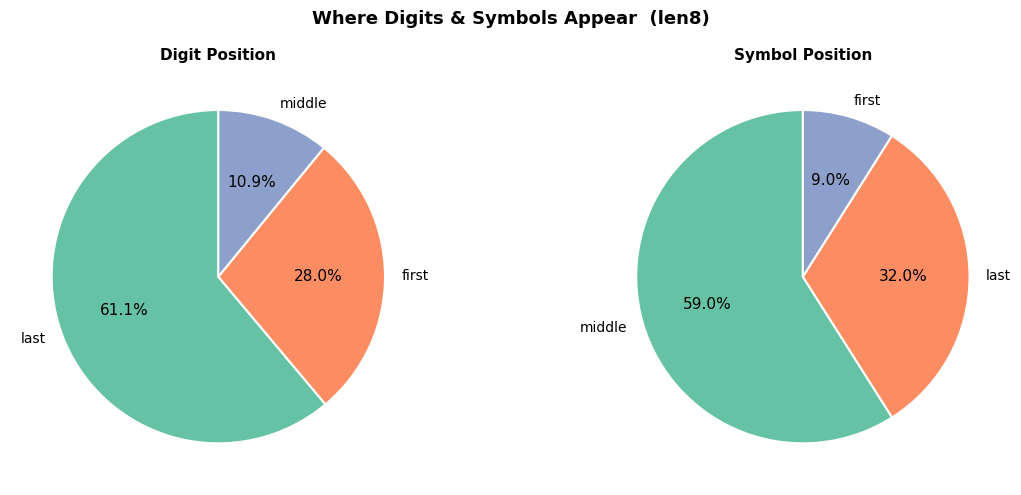

Saved → pcfg_output/pcfg_len8/chart_positions.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"Where Digits & Symbols Appear  ({length_tag})",
             fontsize=13, fontweight='bold')

for ax, key, title in [
    (axes[0], 'digit_positions',  'Digit Position'),
    (axes[1], 'symbol_positions', 'Symbol Position'),
]:
    rows = ruleset[key]
    if not rows:
        ax.set_visible(False)
        continue
    labels = [r['value'] for r in rows]
    vals   = [r['probability'] * 100 for r in rows]
    colors = plt.get_cmap('Set2')(np.arange(len(labels)))
    wedges, texts, autotexts = ax.pie(
        vals, labels=labels, autopct='%1.1f%%',
        colors=colors, startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5)
    )
    for at in autotexts:
        at.set_fontsize(11)
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.tight_layout()
p = os.path.join(OUTPUT_DIR, 'chart_positions.png')
plt.savefig(p, dpi=150)
plt.show()
print(f"Saved → {p}")

## 🔤 Cell 11 — Chart: Top Base Words

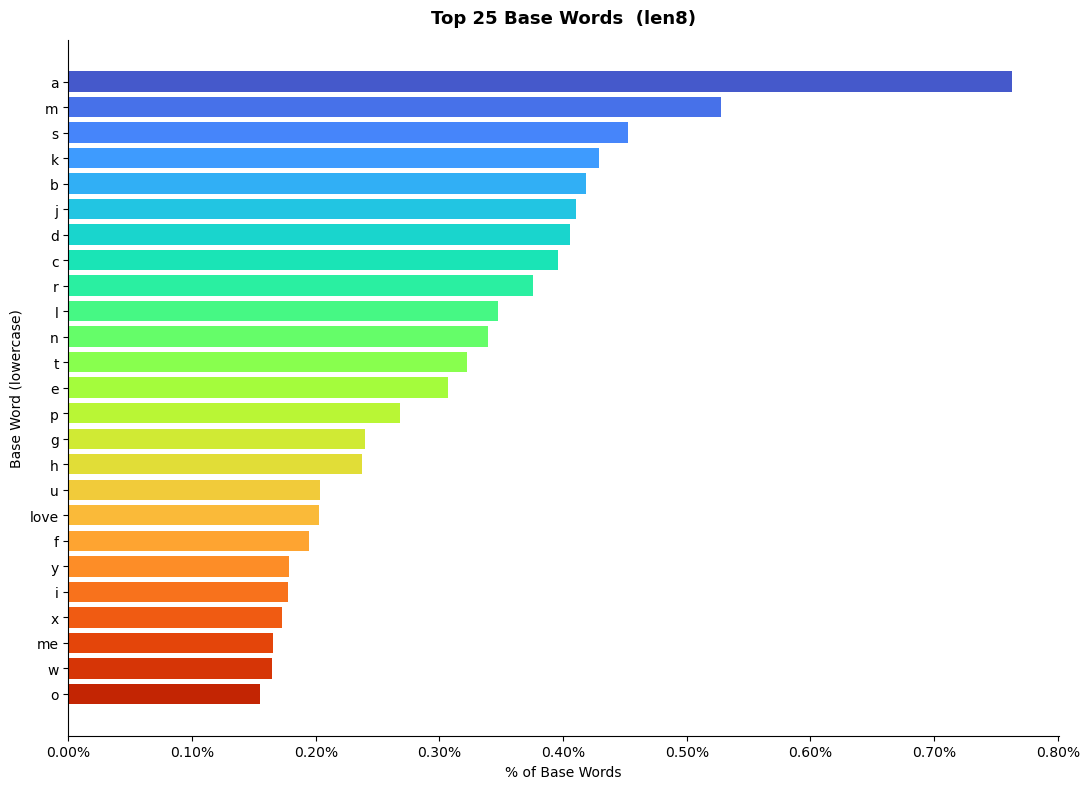

Saved → pcfg_output/pcfg_len8/chart_base_words.png


In [11]:
top = ruleset['base_words'][:25]
if top:
    labels = [r['value'] for r in top]
    values = [r['probability'] * 100 for r in top]
    colors = plt.get_cmap('turbo')(np.linspace(0.1, 0.9, len(labels)))

    fig, ax = plt.subplots(figsize=(11, 8))
    ax.barh(labels[::-1], values[::-1], color=colors[::-1])
    ax.set_title(f"Top 25 Base Words  ({length_tag})",
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel("% of Base Words", fontsize=10)
    ax.set_ylabel("Base Word (lowercase)", fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2f}%"))
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    p = os.path.join(OUTPUT_DIR, 'chart_base_words.png')
    plt.savefig(p, dpi=150)
    plt.show()
    print(f"Saved → {p}")
else:
    print("No base words found — chart skipped")

## ✅ Cell 12 — Summary

In [12]:
output_files = [
    'ruleset.json',
    'probability_tables.txt',
    'chart_structures.png',
    'chart_digits.png',
    'chart_symbols.png',
    'chart_cap_masks.png',
    'chart_positions.png',
    'chart_base_words.png',
]

print("=" * 55)
print("  PCFG TRAINING COMPLETE")
print("=" * 55)
print(f"  Input file  : {INPUT_FILE}")
print(f"  Passwords   : {total:,}")
print(f"  Output dir  : {OUTPUT_DIR}")
print()
print("  Files generated:")
for fname in output_files:
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath) / 1024
        print(f"{fname:<35} {size:>7.1f} KB")
    else:
        print(f"{fname:<35} not generated")
print("=" * 55)
print(f"\n  To train a different length, update INPUT_FILE")
print(f"  in Cell 1 and re-run all cells.")

  PCFG TRAINING COMPLETE
  Input file  : split_output/rockyou_len8.txt
  Passwords   : 2,966,956
  Output dir  : pcfg_output/pcfg_len8

  Files generated:
ruleset.json                        114775.0 KB
probability_tables.txt                  9.6 KB
chart_structures.png                   59.3 KB
chart_digits.png                       40.8 KB
chart_symbols.png                      40.6 KB
chart_cap_masks.png                    37.9 KB
chart_positions.png                    78.6 KB
chart_base_words.png                   46.3 KB

  To train a different length, update INPUT_FILE
  in Cell 1 and re-run all cells.
